# EDA Agrupación por Industria


En este notebook se realizara un analisis exploratorio despues de las agrupaciones y de la limpeza de los datos a ver como se organizan los nuevos generos. En esta agrupación titulada **Industria** en esta si tiene otro enfoque en el cual se agrupan en que tipo de industria separan los generos


|    | Grupo Resultante  | Géneros Incluidos                          | Justificación                                                                             
|-------|-------------------|--------------------------------------------|-------------------------------------------------------------------------------------------
|1| pop_rock          | Pop, Dance, Indie, Alternative, Rock       | El núcleo de la música popular contemporánea de bandas y solistas.                        |   |   |
|2| urban             | Hip-Hop, Rap, Reggaeton, Reggae, Ska       | Géneros de movimiento urbano y herencia rítmica latina/caribeña.                          |   |   |
|3| roots_and_soul    | Folk, Country, World, Blues, Soul, R&B     | Música con fuertes raíces culturales, tradicionales o de enfoque vocal orgánico.          |   |   |
|4| fine_arts         | Classical, Opera, Jazz                     | Música académica o de alta complejidad técnica interpretativa.                            |   |   |
|5| media_and_screen  | Soundtrack, Movie, Anime, Video Game Music | Música compuesta específicamente para acompañar contenido visual.                         |   |   |
|6| specialty_content | Children's Music, Comedy                   | Contenido que tiene un propósito específico no necesariamente musical (humor o infantil). |   |   |
|7| unclassified      | Cualquier otro género                      | Categoría de seguridad para datos nuevos o ruidosos.                                      |

In [1]:
import sys
import os
import importlib
import warnings
warnings.filterwarnings("ignore")

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import src.features.preprocessing_6 as prep
importlib.reload(prep) 

df, x, y = prep.preprocessing()

df.head(5)

,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence,es_muy_larga,genre_grouped
0,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814,False,media_and_screen
1,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816,False,media_and_screen
2,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368,False,media_and_screen
3,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227,False,media_and_screen
4,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390,False,media_and_screen


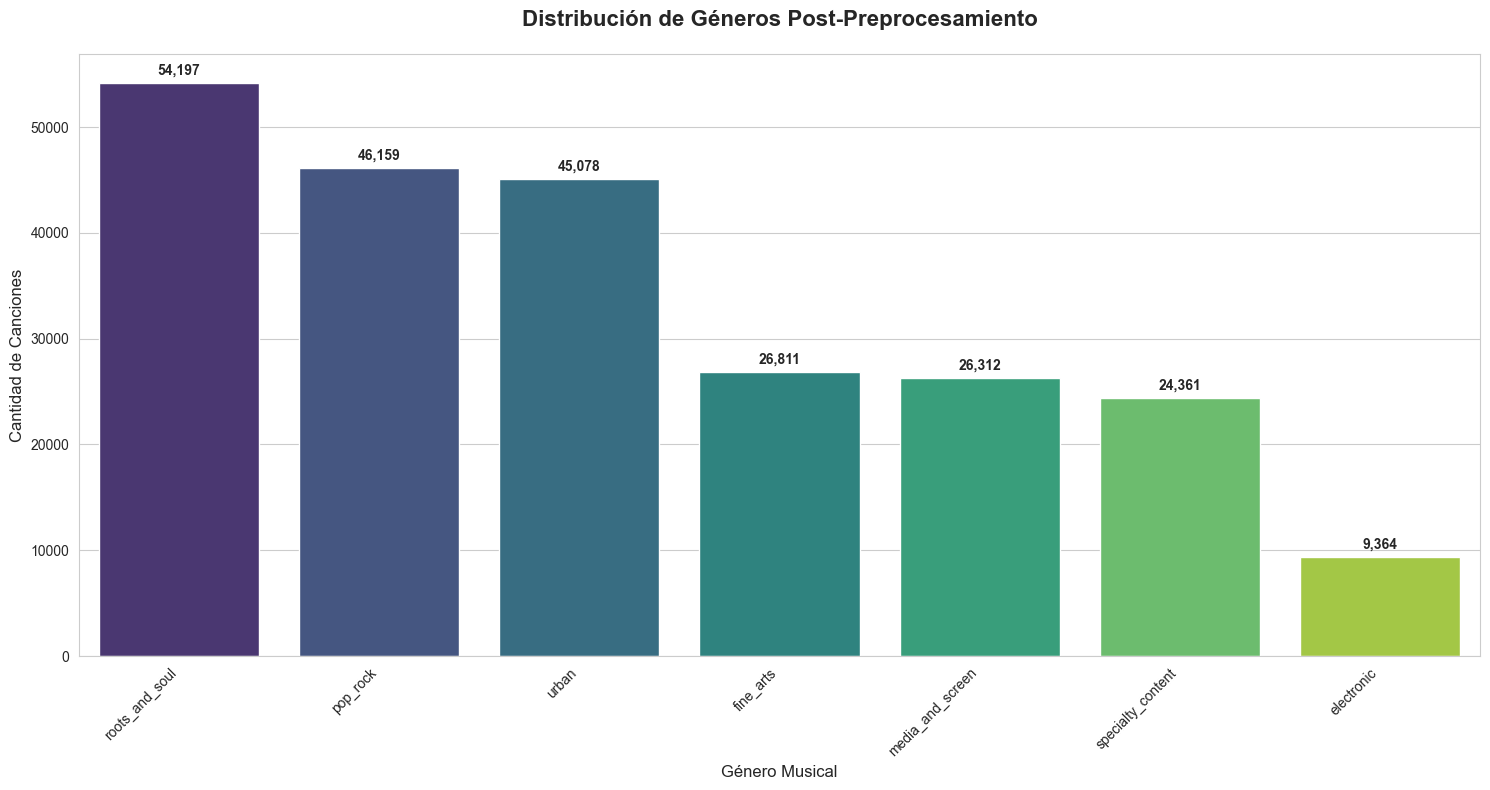

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

genre_counts = df['genre_grouped'].value_counts()

plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values, palette='viridis')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=10, fontweight='bold')
    
plt.title('Distribución de Géneros Post-Preprocesamiento', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Género Musical', fontsize=12)
plt.ylabel('Cantidad de Canciones', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [3]:
stats_despues = {
    'Num. Clases': df['genre_grouped'].nunique(),
    'Mínimo muestras': df['genre_grouped'].value_counts().min(),
    'Máximo muestras': df['genre_grouped'].value_counts().max(),
    'Promedio por clase': df['genre_grouped'].value_counts().mean()
}

stats_despues

{'Num. Clases': 7,
 'Mínimo muestras': 9364,
 'Máximo muestras': 54197,
 'Promedio por clase': 33183.142857142855}

EDA_Industrias

Como se menciono anteriormente una vez que se realizo la limpieza de datos, se agruparon los generos que ahora se pueden observar en la grafica, pero tal como se puede obvservar en la Grafica, esta presenta un desbalanceo moderado con 2 de los 6 grupos pero con los demas presenta un desbalanceo consireable, esto se debe a que la cantidad de datos presentadas en el grupo "roots_and_soul" contiene 54281 datos a diferencia del grupo que menor cantidad de datos que "electronic" que tan solo tiene 9377 datos, eso es una diferencia de casi 6 veces la cantidad, y esto se puede notar en el promedio de datos por cada grupo que se muestra como aproximadamente 33245 por clase, una cifra claramente inflada a causa de "roots_and_soul", por lo tanto se deben aplicar tecnicas de balanceo antes de que los dats pasen por el modelo

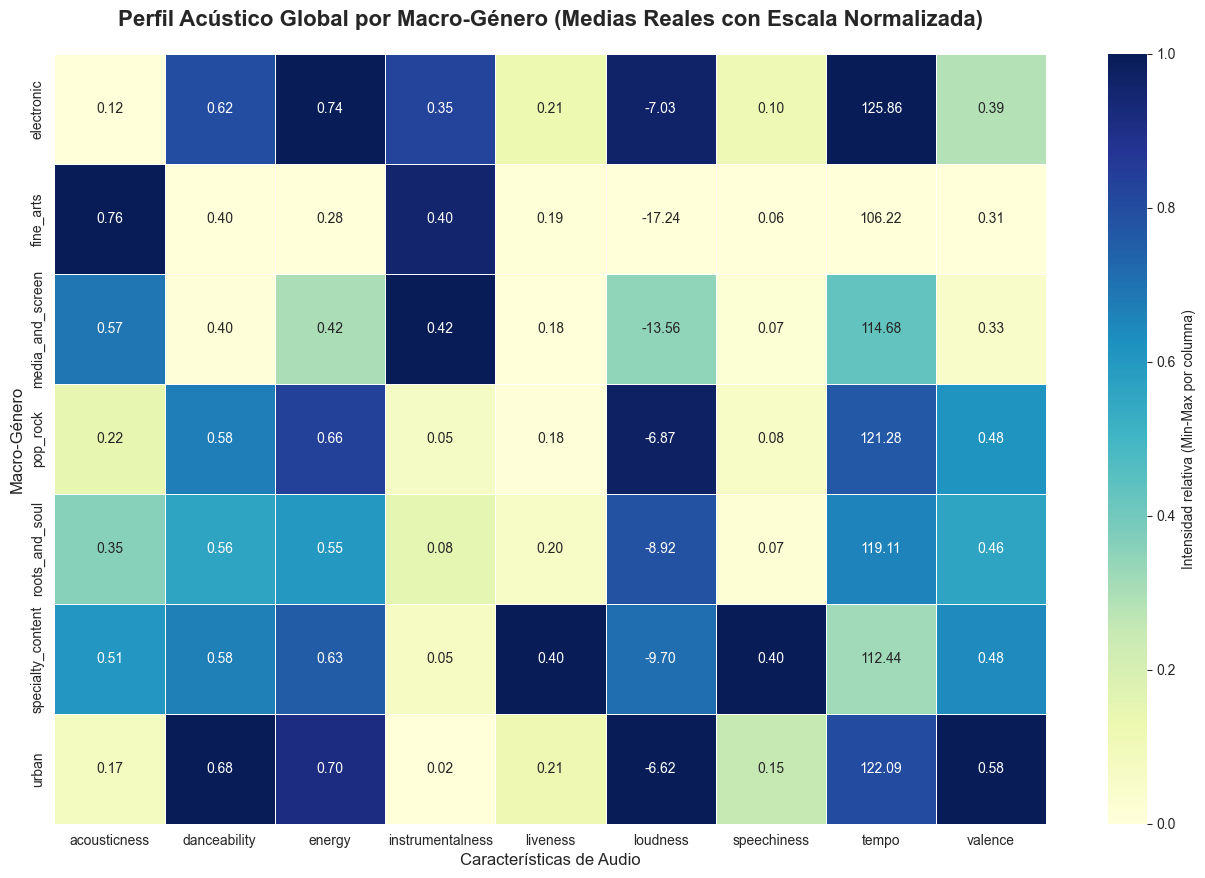

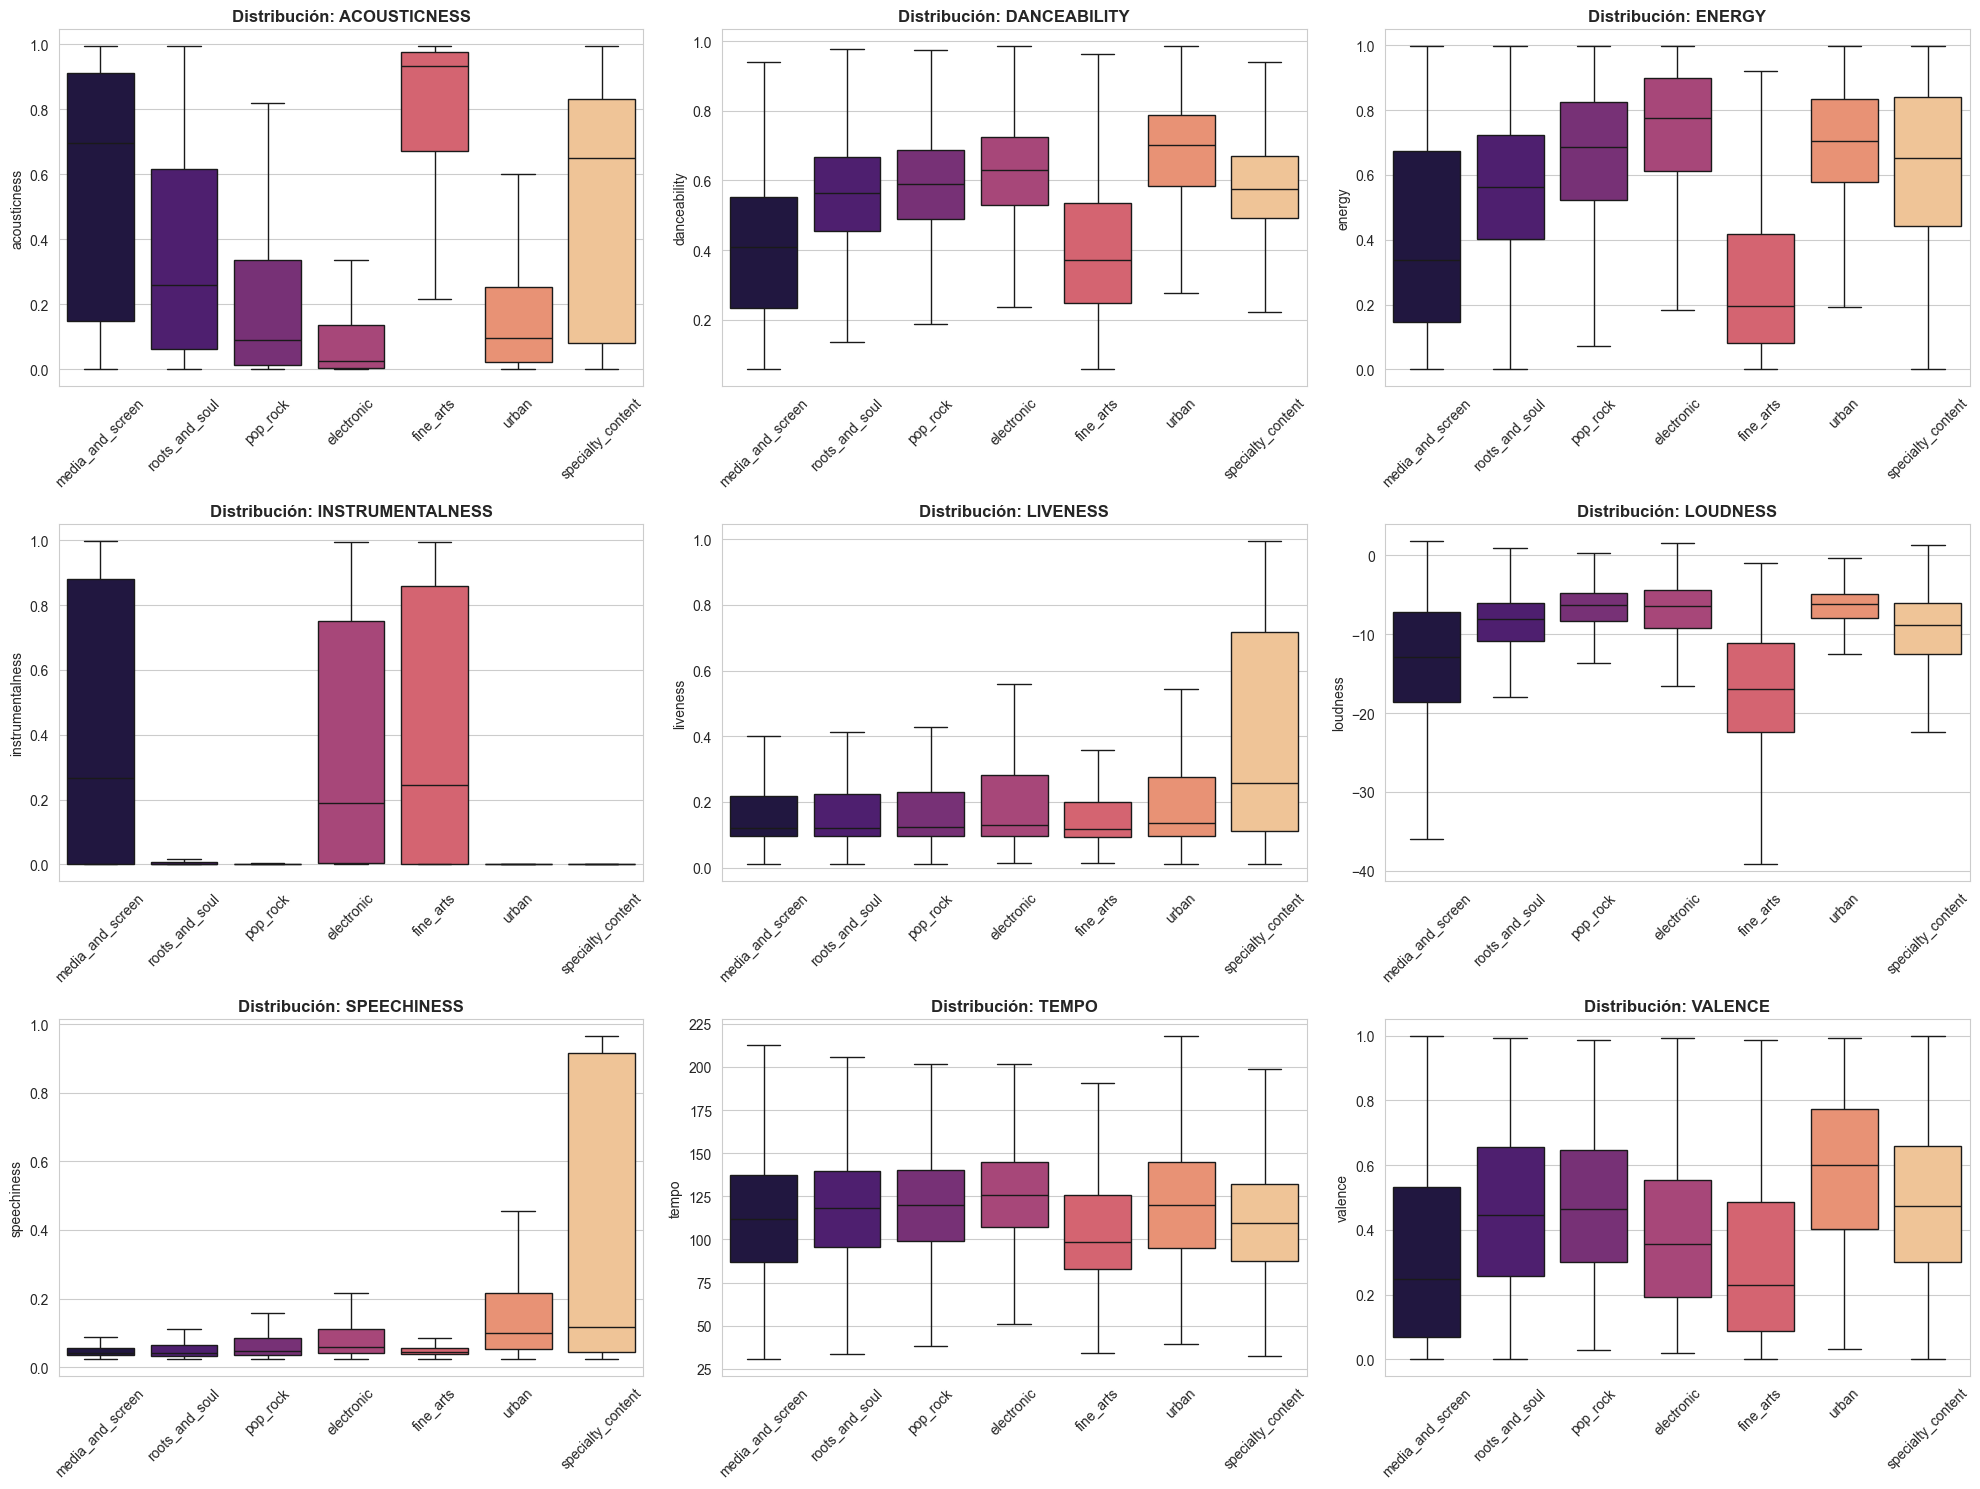

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Matriz de correlación para las variables numéricas
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
for col in ['duration_ms', 'key', 'mode', 'time_signature', 'popularity']:
    if col in cols_numericas: cols_numericas.remove(col)
perfil_medios = df.groupby('genre_grouped')[cols_numericas].mean()
perfil_norm = (perfil_medios - perfil_medios.min()) / (perfil_medios.max() - perfil_medios.min())

plt.figure(figsize=(16, 10))
sns.heatmap(perfil_norm, 
            annot=perfil_medios,
            fmt=".2f", 
            cmap='YlGnBu', 
            linewidths=.5,
            cbar_kws={'label': 'Intensidad relativa (Min-Max por columna)'})

plt.title('Perfil Acústico Global por Macro-Género (Medias Reales con Escala Normalizada)', 
          fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Macro-Género', fontsize=12)
plt.xlabel('Características de Audio', fontsize=12)
plt.show()

# Boxplots com respecto a 'genre_grouped' para cada variable numérica

n_cols = 3
n_rows = (len(cols_numericas) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    sns.boxplot(x='genre_grouped', y=col, data=df, ax=axes[i], palette='magma', showfliers=False)
    axes[i].set_title(f'Distribución: {col.upper()}', fontsize=12, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

| Macro-Grupo       | Característica   | Valor  | Fuerza (%) | Interpretación                |
| ----------------- | ---------------- | ------ | ---------- | ----------------------------- |
| electronic        | energy           | 0.74   | 74%        | Muy energético                |
| electronic        | danceability     | 0.62   | 62%        | Altamente bailable            |
| electronic        | tempo            | 125.85 | —          | Ritmo rápido (no normalizado) |
| fine_arts         | acousticness     | 0.76   | 76%        | Predominio acústico           |
| fine_arts         | instrumentalness | 0.40   | 40%        | Mayor presencia instrumental  |
| media_and_screen  | instrumentalness | 0.42   | 42%        | Música funcional (sin voz)    |
| media_and_screen  | acousticness     | 0.57   | 57%        | Tendencia a sonidos naturales |
| pop_rock          | energy           | 0.66   | 66%        | Energía alta                  |
| pop_rock          | danceability     | 0.58   | 58%        | Moderadamente bailable        |
| roots_and_soul    | danceability     | 0.56   | 56%        | Ritmo moderado                |
| roots_and_soul    | energy           | 0.55   | 55%        | Energía media                 |
| specialty_content | speechiness      | 0.40   | 40%        | Alta presencia de voz hablada |
| specialty_content | liveness         | 0.40   | 40%        | Contenido tipo en vivo        |
| urban             | energy           | 0.70   | 70%        | Alta intensidad               |
| urban             | danceability     | 0.68   | 68%        | Muy bailable                  |
| urban             | valence          | 0.58   | 58%        | Emoción positiva              |

| Relación                  | Fuerza |
| ------------------------- | ------ |
| acousticness ↔️ fine_arts  | 76%    |
| energy ↔️ electronic       | 74%    |
| energy ↔️ urban            | 70%    |
| danceability ↔️ urban      | 68%    |
| energy ↔️ pop_rock         | 66%    |
| danceability ↔️ electronic | 62%    |

A partir de la tabla de correlacion entre el Macro-Grupo Industriay las caracteristicas de audio se identificaron algunas correlacion de linealidad bastante fuertes, tal como "acousticness" con "fine_arts " con un 76% de correlacion, por tanto se consideran como variables a considerar que pueden ayudar a la prediccion de los modelos

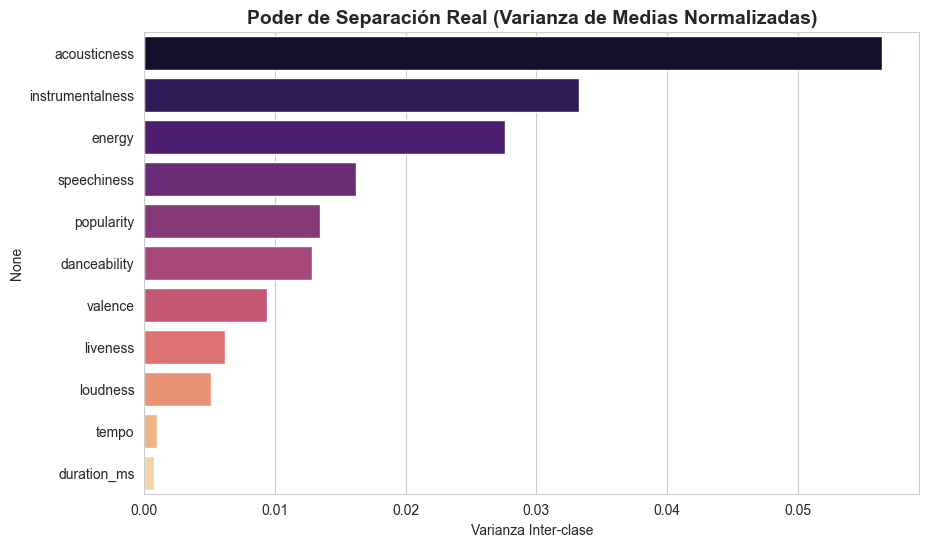

acousticness        0.056496
instrumentalness    0.033299
energy              0.027623
speechiness         0.016180
popularity          0.013436
danceability        0.012870
valence             0.009380
liveness            0.006155
loudness            0.005082
tempo               0.000991
duration_ms         0.000757
dtype: float64


In [5]:
from sklearn.preprocessing import MinMaxScaler

# 1. Seleccionamos solo las cuantitativas
cols_cuantitativas = df.select_dtypes(include=[np.number]).columns.tolist()

# 2. Normalizamos temporalmente para que todas valgan lo mismo (escala 0-1)
scaler = MinMaxScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[cols_cuantitativas]), columns=cols_cuantitativas)
df_scaled['genre_grouped'] = df['genre_grouped'].values

# 3. Calculamos la Varianza de las Medias
# Esto mide qué tanto se alejan los promedios de los grupos entre sí
ranking_separacion = df_scaled.groupby('genre_grouped').mean().var().sort_values(ascending=False)

# 4. Visualización
plt.figure(figsize=(10, 6))
sns.barplot(x=ranking_separacion.values, y=ranking_separacion.index, palette='magma')
plt.title('Poder de Separación Real (Varianza de Medias Normalizadas)', fontsize=14, fontweight='bold')
plt.xlabel('Varianza Inter-clase')
plt.show()

print(ranking_separacion)

Al analizar la varianza y medias presentados en las grafiicas de boxsplot separados por caracteristicas de audios, con el grupo de generos, se identifico que las variables "acousticness" y "instrumentalness" tienen un poder discriminatorio particularmente alto siendo, teniendo una varianza de 0.056635 y 0.033330 respectivamente cada uno, se consideran variables importantes al momento de utilizarlas en el modelo ya que estas pueden distinguir mejor entre los grupos de Industria

Conclucion
En este notebook se realizo un analisis exploratorio de la nueva agrupacion de los generos luego de su limpieza de datos, a continuacion se presentaran lo siguiente hallazgos
* Presenta un desbalance entre las variables del grupo, por tanto se debe realizar un balanceo antes de que los datos pasen por el modelo predictivo
* A partir de las graficas del notebook se identificaron algunas variables con una fuerte correlacion lineal tal como "acousticness" con "fine_arts " alcanzando una correlacion de hasta el 76%
* e identificaron dos variables con un fuerte poder discriminatorio de "caracteristicas de audio" que son "instrumentalness" y "acousticness", estas dos variables tienen un fuerte poder discriminatorio muy util a la hora de poder distinguir entre los macro generos
* En base a estos hallasgos se considerara el recall como medida de exito